# Table of Contents

* [1.1 Introduction](#1.1-Introduction)
* [1.2 Preparation](#1.2-Preparation)
    * [1.2.1 Import the dataset](#1.2.1-Import-the-dataset)
* [1.3 Dataset Summary ](#1.3-Dataset-Summary)
* [1.4 Missing Values and Duplicates analysis](#1.4-Missing-Values-and-Duplicates-analysis)
    * [1.4.1 Missing Values](#1.4.1-Missing-Values)
    * [1.4.2 Duplicates](#1.4.2-Duplicates)
* [1.5 Univariate Analysis](#1.5-Univariate-Analysis)
    * [1.5.1 Numerical Variables](#1.5.1-Numerical-Variables)
    * [1.5.2 Categorical Variables](#1.5.3-Categorical-Variables)
* [1.6 Feature Engeering](#1.7-Final-Insights) 
* [1.7 Bivariate Analysis](#1.6-Bivariate-Analysis)
    * [1.7.1 Correlation Matrix](#1.6.1-Correlation-Matrix)
* [1.8 Final Insights](#1.7-Final-Insights)

# 1.1 Introduction

This notebook performs an Exploratory Data Analysis (EDA) on the `customer_info.csv` dataset. We focus on data quality (missing values, duplicates, outliers) and feature engineering to prepare the data for predictive modeling.

In this notebook we also perform feature engineering and correct some datatypes. Preprocessing will be implemented later as a separate function.

# 1.2 Preparation

Loading necessary libraries and setting plot styles.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from datetime import datetime
from shapely.geometry import Point, box, Polygon, LineString
import math


ModuleNotFoundError: No module named 'geopandas'

## 1.2.1 Import the dataset

In [ ]:
file_path = 'C:\\Users\\maria\\Documents\\Universidade\\Machine Learning II\\Customer-Segmentation-Project\\Course Assignment - Customer Segmentation-20260417\\customer_info.csv'
df = pd.read_csv(file_path)

# 1.3 Dataset Summary

In [ ]:
df.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [ ]:
df.set_index('customer_id', drop=True, inplace=True)
df.head()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [ ]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables           

In [ ]:
print("\nNumerical Description:")
df.describe().T


Numerical Description:


,count,mean,std,min,25%,50%,75%,max
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000
lifetime_spend_alcohol_drinks,32708.0,622.144185,517.744320,0.000000,201.000000,483.000000,891.250000,3704.000000


# 1.4 Missing Values and Duplicates analysis

## 1.4.1 Missing Values

In [ ]:
null_counts = df.isnull().sum()
missing_df = pd.DataFrame({
    'Missing Values': null_counts
}).sort_values(by='Missing Values', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] >= 0])

Missing Values Summary:
                                         Missing Values
loyalty_card_number                               13106
lifetime_spend_fish                                 991
typical_hour                                        661
lifetime_spend_electronics                          661
lifetime_spend_videogames                           661
lifetime_spend_meat                                 661
lifetime_spend_vegetables                           661
lifetime_spend_petfood                              661
number_complaints                                   661
percentage_of_products_bought_promotion             330
distinct_stores_visited                             330
teens_home                                          330
kids_home                                           330
lifetime_spend_hygiene                              330
lifetime_spend_alcohol_drinks                       330
customer_birthdate                                  165
latitude                

Most features have a manageable number of missing values — around 330 to 991 rows — likely corresponding to the same subset of customers with incomplete records, suggesting the missingness is structural rather than random. 

The clear outlier is `loyalty_card_number` with **13,106 missing values**. This is almost certainly not random — it simply means those customers do not have a loyalty card, so its absence is meaningful in itself. Imputing this column would make no sense, and since it is a pure identifier with no behavioural signal, it will be dropped entirely in preprocessing

## 1.4.2 Duplicates

This section verifies whether the dataset contains repeated entries.
- `df.duplicated().sum()` counts rows that are exactly the same across all columns.
- `df['customer_id'].duplicated().sum()` checks whether the same customer ID appears more than once.

A duplicate customer ID is important because `customer_id` should uniquely identify each customer. If the same ID repeats, the dataset may contain:
- exact duplicate records, or
- conflicting information for the same customer. 

In [ ]:
print(f"Full row duplicates: {df.duplicated().sum()}")


Full row duplicates: 0


# 1.5 Univariate Analysis

## 1.5.1 Numerical Variables

Here we are selecting the numerical variables for  some analysis, even thought the *id* feature is considered a numerical variable we´re not considering it for the future analysis because there is no pattern or relevant information for our future model since it's only an identification of our records

In [ ]:
numeric_cols = [
    "kids_home",
    "teens_home",
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_spend_groceries",
    "lifetime_spend_electronics",
    "typical_hour",
    "lifetime_spend_vegetables",
    "lifetime_spend_nonalcohol_drinks",
    "lifetime_spend_alcohol_drinks",
    "lifetime_spend_meat",
    "lifetime_spend_fish",
    "lifetime_spend_hygiene",
    "lifetime_spend_videogames",
    "lifetime_spend_petfood",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "year_first_transaction",
    "loyalty_card_number",
    "latitude",
    "longitude"
]

In [ ]:
num_cols = df.drop(columns=['customer_name','customer_gender','customer_birthdate'])

### Constant Variables

In [ ]:
num_cols.var()

kids_home                                  1.322927e+00
teens_home                                 9.272217e-01
number_complaints                          8.004128e-01
distinct_stores_visited                    2.802657e+00
lifetime_spend_groceries                   1.436619e+08
lifetime_spend_electronics                 1.192453e+07
typical_hour                               2.356819e+01
lifetime_spend_vegetables                  4.285445e+05
lifetime_spend_nonalcohol_drinks           7.604798e+04
lifetime_spend_alcohol_drinks              2.680592e+05
lifetime_spend_meat                        2.333110e+05
lifetime_spend_fish                        2.470775e+05
lifetime_spend_hygiene                     3.700500e+05
lifetime_spend_videogames                  2.123201e+05
lifetime_spend_petfood                     2.567525e+04
lifetime_total_distinct_products           1.121966e+04
percentage_of_products_bought_promotion    8.045041e-02
year_first_transaction                     2.532

Checking for constant variables — features with zero variance that carry no information for clustering — only `loyalty_card_number` has a variance of exactly **0.0**, confirming it is a constant and will be dropped in preprocessing.

All other features show non-zero variance. Notably, `latitude` and `longitude` have extremely low variance (~5e-04 and ~8e-04 respectively).While not technically constant, their near-zero variance makes them unlikely to contribute meaningful separation in clustering, so they will likely be dropped as well.

### Distribution of each feature 
Histograms help visualize how each numeric variable is distributed, showing skewness, central tendency, and spread.

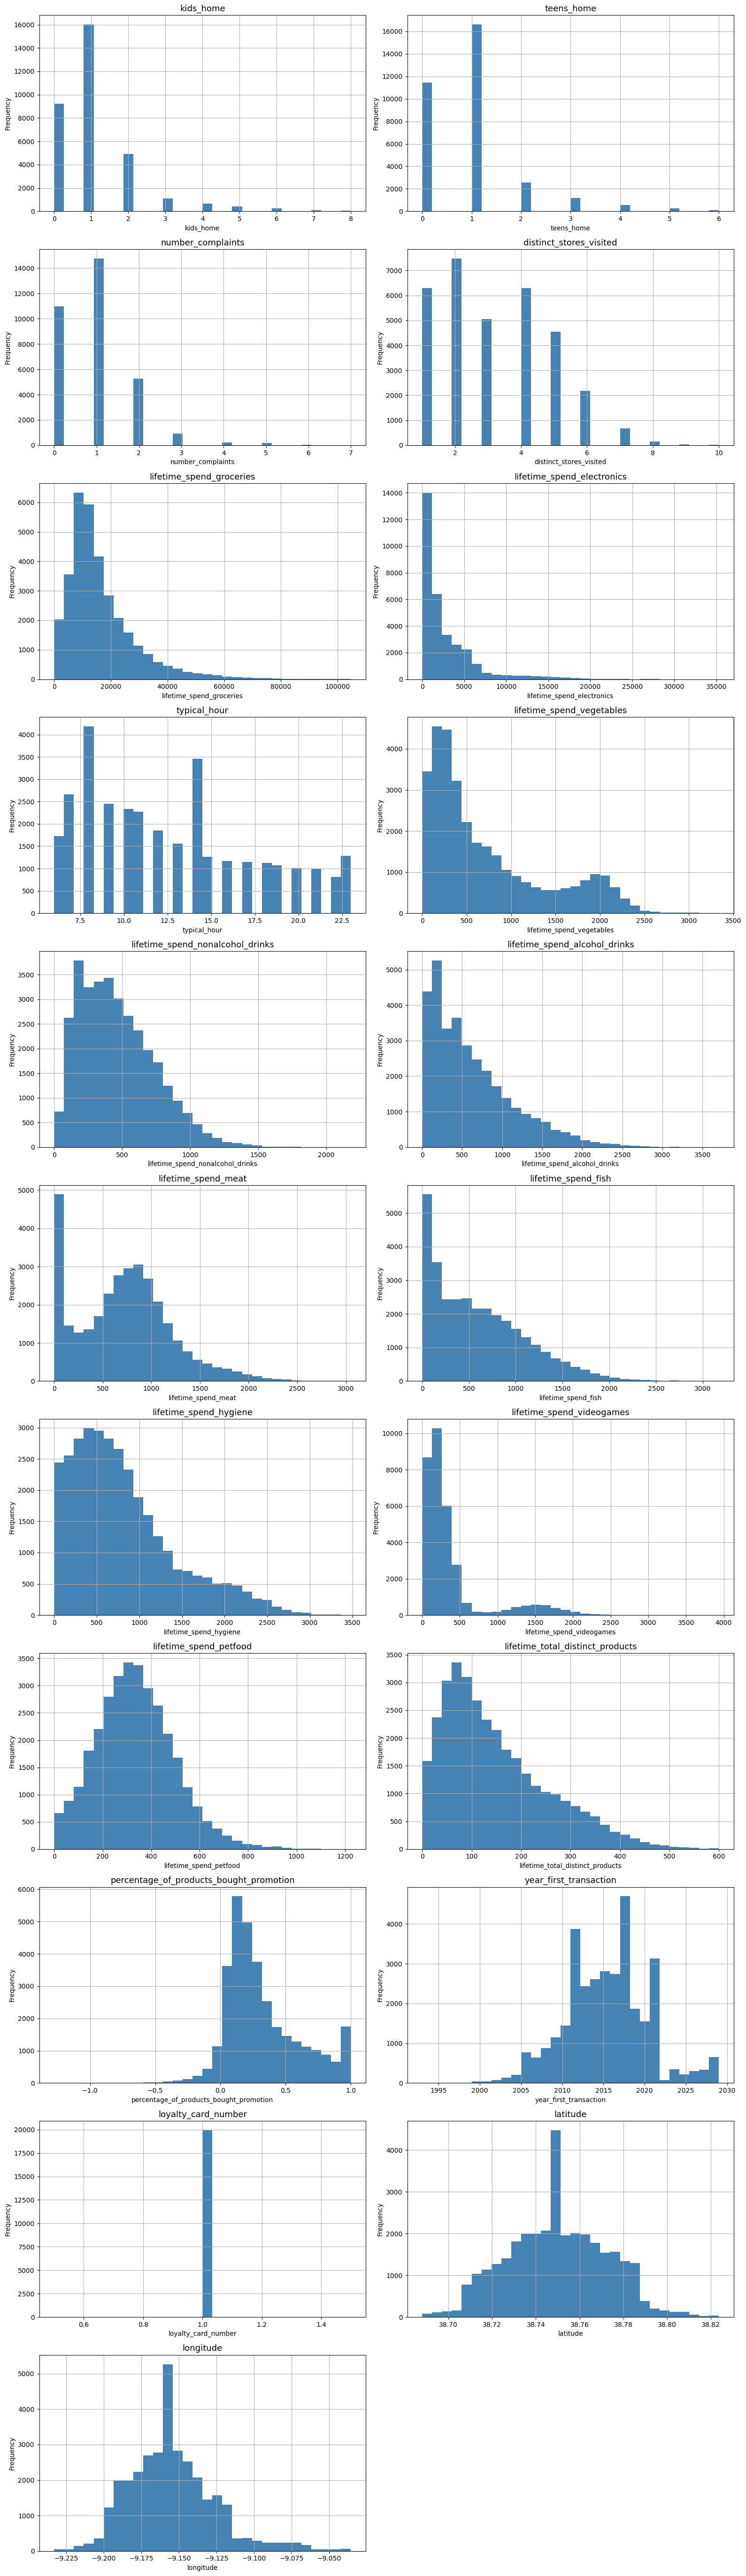

In [ ]:
cols_per_row = 2
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, color='steelblue', ax=axes[i])
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Esconder eixos vazios se o número de colunas for ímpar
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Conclusions about the Numerical Data Distribution

After analyzing the histograms above, several insights can be drawn regarding the distribution of the numerical features.

### The Shape of the Distributions

We can characterize the overall shape of each variable based on its histogram:

- **Right-Skewed Variables (log transformation candidates):** `lifetime_spend_groceries`, `lifetime_spend_electronics`, `lifetime_spend_vegetables`, `lifetime_spend_nonalcohol_drinks`, `lifetime_spend_alcohol_drinks`, `lifetime_spend_meat`, `lifetime_spend_fish`, `lifetime_spend_hygiene`, `lifetime_spend_petfood`, `lifetime_total_distinct_products` and `lifetime_spend_videogames` have most observations concentrated near zero, with a long right tail representing a few high spenders. We will apply log transformation to these features in the preprocessing phase to make their distributions more normal.

- **Approximately Normal (no action needed):** `lifetime_spend_petfood` show a roughly symmetric, bell-shaped distribution, indicating consistent spending behaviour across customers.

- **Uniform-like:** `distinct_stores_visited` is relatively spread across its range with no dominant peak, suggesting customers visit a varied number of stores without a clear pattern.

- **Discrete / Sparse:** `kids_home`, `teens_home` and `number_complaints` are heavily concentrated at 0 and 1 with very few higher values. These are low-variance features and their usefulness for clustering should be evaluated.

### Other Notes

`typical_hour` shows a bimodal pattern with peaks around 8–9am and 15pm, which could be meaningful for segmentation. `year_first_transaction` has visible spikes that likely reflect onboarding campaigns or data collection changes over the years. `percentage_of_products_bought_promotion` presents negative values, which is worth investigating before preprocessing. Finally, `loyalty_card_number` will be dropped as it is a pure identifier with no distributional value.


### Whiskers and Outliers

This section uses boxplots to visually identify outliers and compare the spread of numerical variables.

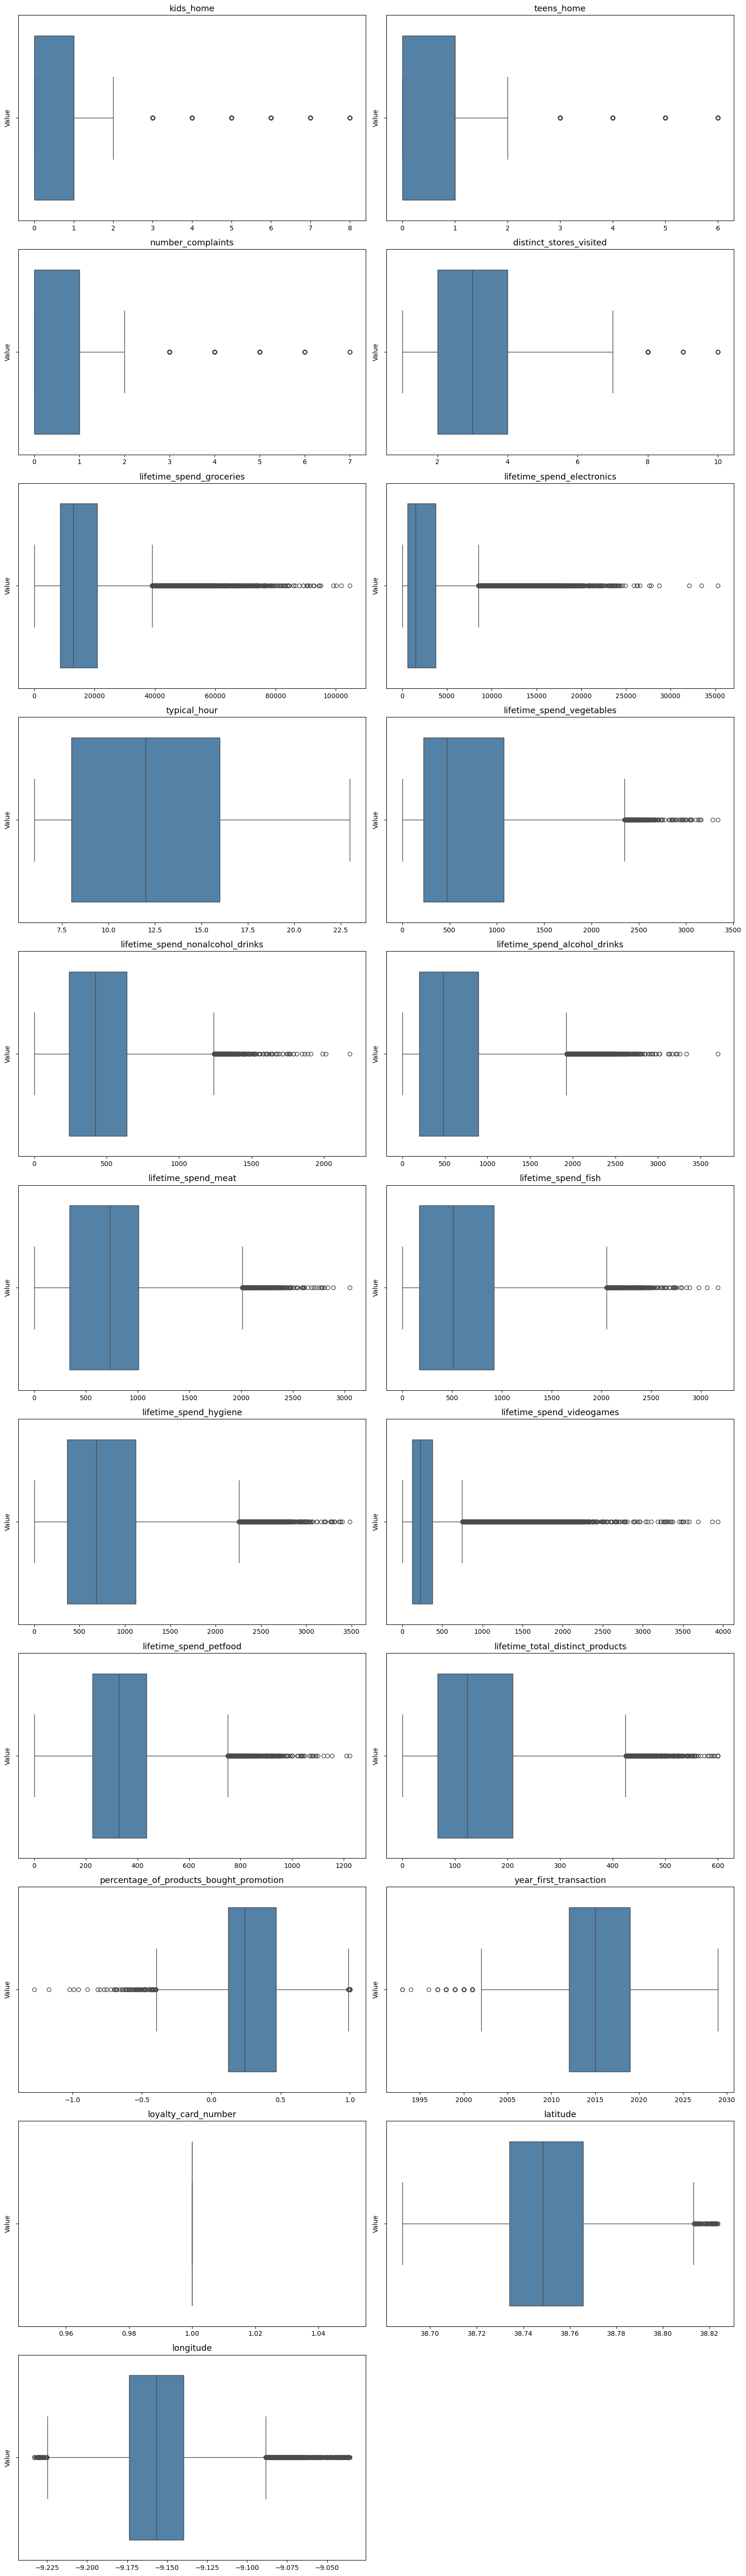

In [ ]:
cols_per_row = 2
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], color='steelblue', ax=axes[i])
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value')

for ax in axes[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Conclusions about the Outliers

After analyzing the boxplots above, several insights can be drawn regarding the presence and severity of outliers across features.

### Outlier Severity

We can characterize each variable by its outlier behaviour:

- **Heavy outliers (require treatment):** `lifetime_spend_groceries`, `lifetime_spend_electronics`, `lifetime_spend_nonalcohol_drinks`, `lifetime_spend_alcohol_drinks`, `lifetime_spend_meat`, `lifetime_spend_fish`, `lifetime_spend_hygiene`, `lifetime_spend_videogames`, `lifetime_spend_petfood` and `lifetime_total_distinct_products` all show a dense cloud of outliers stretching far into the right tail. These are consistent with the right-skewed distributions observed in the histograms, and confirm that log transformation followed by outlier capping will be necessary in preprocessing.

- **Moderate outliers (worth monitoring):** `kids_home`, `teens_home`, `number_complaints` and `lifetime_spend_vegetables` show a small number of isolated outlier points beyond the whiskers. Given that these are discrete or low-variance features, the outliers likely represent genuine edge cases rather than noise.

- **No meaningful outliers:** `distinct_stores_visited` and `typical_hour` show clean distributions with whiskers covering most of the range and very few points outside, suggesting no aggressive treatment is needed.

### Other Notes

`percentage_of_products_bought_promotion` shows outliers on the **left tail**, around -1.0, reinforcing the data quality concern raised in the histogram analysis — negative percentages are not interpretable and should be investigated. `year_first_transaction` has a few early outliers around 1995–2000, which likely correspond to the oldest customers in the dataset. `loyalty_card_number` shows no variance whatsoever in the boxplot, further confirming it should be dropped. `latitude` and `longitude` both present outlier clusters at the edges of their ranges, but given the overall tight geographic spread, these likely just reflect customers at the boundary of the Lisbon area.

### Percentage of products bought promotion 

In [ ]:
neg_mask = df['percentage_of_products_bought_promotion'] < 0
print(f"Number of negative values: {neg_mask.sum()}")
print(f"Percentage of dataset: {(neg_mask.sum() / len(df) * 100):.2f}%")

Number of negative values: 1755
Percentage of dataset: 5.31%


In [ ]:
df.loc[df['percentage_of_products_bought_promotion'] < 0, 'percentage_of_products_bought_promotion'] = np.nan

### Typical hour

C:\Users\maria\AppData\Local\Temp\ipykernel_3764\1418484860.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='typical_hour', data=df,palette= 'crest')


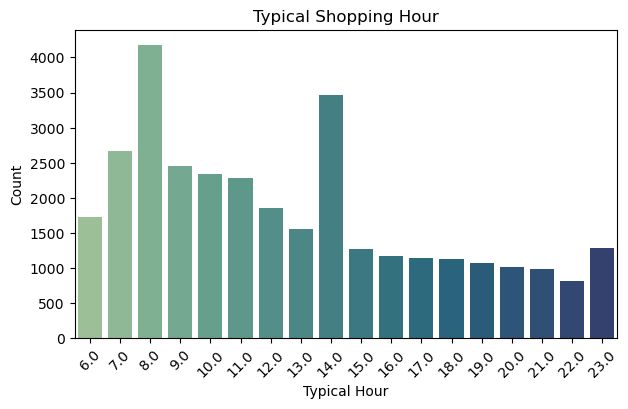

In [ ]:
#Shopping hour
plt.figure(figsize=(7, 4))
sns.countplot(x='typical_hour', data=df,palette= 'crest')
plt.title('Typical Shopping Hour')
plt.xlabel('Typical Hour')
plt.ylabel('Count')

# Rotate x-axis labels
plt.xticks(rotation=45)  # Adjust the rotation angle as needed

plt.show()

### Geographical Anaylsis

In [ ]:
customer_info_gd = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
customer_info_gd.drop(columns=['latitude', 'longitude'], inplace=True)
customer_info_gd.head()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,geometry
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,...,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,POINT (-9.21574 38.79443)
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,...,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,POINT (-9.17961 38.75171)
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,...,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,POINT (-9.16066 38.78068)
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,POINT (-9.14868 38.73955)
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,POINT (-9.18819 38.73307)


In [ ]:
customer_info_gd.iloc[0:1000].explore()

## 1.5.2 Categorical Variables

### Customer Gender

The values are nearly balanced.

In [ ]:
df['customer_gender'].value_counts()

customer_gender
female    16577
male      16461
Name: count, dtype: int64

### Customer Birthdate

In this section we convert `customer_birthdate` to a datetime type and compute an `age` feature (in years). This `age` will be used for analysis and downstream modelling instead of separate birth month/day/year fields.

C:\Users\maria\AppData\Local\Temp\ipykernel_3764\2622435473.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['customer_birthdate'] = pd.to_datetime(df['customer_birthdate'], errors='coerce')


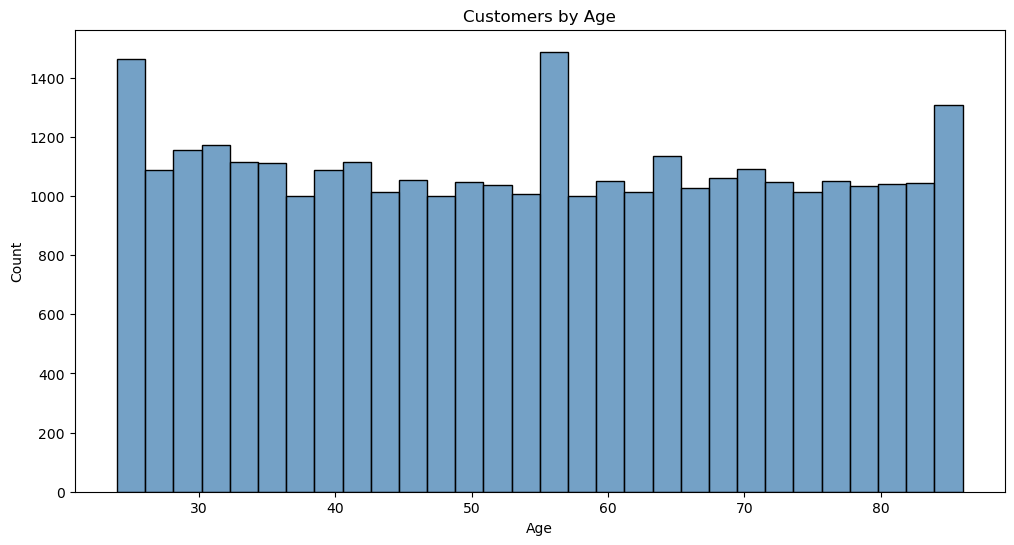

In [ ]:
df['customer_birthdate'] = pd.to_datetime(df['customer_birthdate'], errors='coerce')
# Calculate age in years (approximate)
today = pd.Timestamp('today')
df['age'] = (today - df['customer_birthdate']).dt.days // 365
# Drop the original birthdate column; we only keep `age`
df.drop(columns=['customer_birthdate'], inplace=True)

plt.figure(figsize=(12, 6))
ax = sns.histplot(data=df, x='age', bins=30, color='steelblue')
ax.set_title('Customers by Age')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.show()

The distribution of customers by age is remarkably **uniform across the observed range**, indicating the dataset may have been **synthetically generated or balanced by age**. In real-world data, age distributions are rarely this evenly spread.


# 1.6 Feature Engeering

In [ ]:
# Map values in the 'customer_gender' column
df['female'] = df['customer_gender'].map({'male': 0, 'female': 1})
df.drop(columns=['customer_gender'], inplace=True)
df.head()

,customer_name,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude,age,female
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,...,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739,56.0,1
4,Bsc. Glenda Bauman,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,...,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611,50.0,1
5,Msc. Antonio Campbell,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,...,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656,54.0,0
7,John Kelling,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,...,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679,43.0,0
8,Arthur Dematteo,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,...,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188,56.0,0


In [ ]:
df['total_kids'] = df['kids_home'] + df['teens_home']

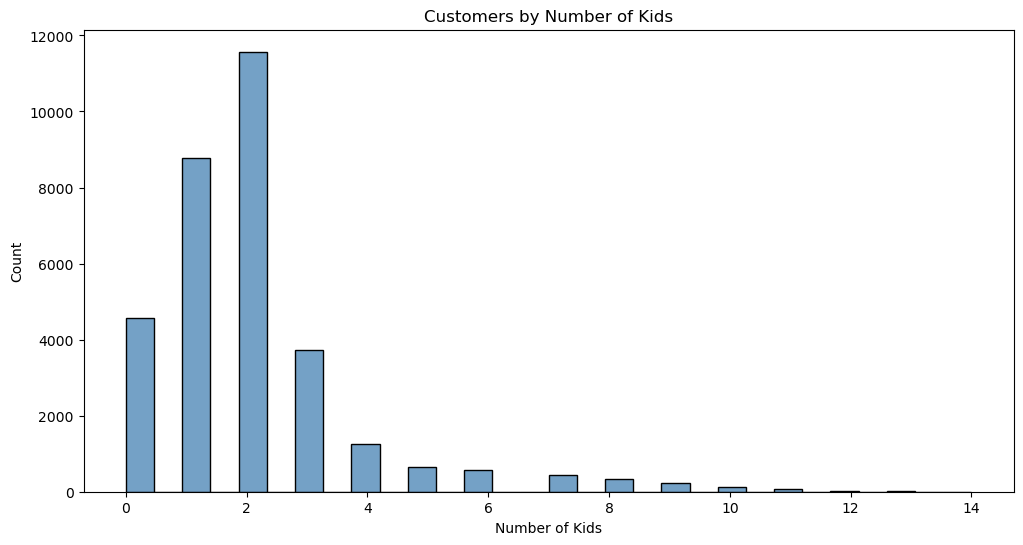

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=df, x='total_kids', bins=30, color='steelblue')
ax.set_title('Customers by Number of Kids')
ax.set_xlabel('Number of Kids')
ax.set_ylabel('Count')
plt.show()

In [ ]:
spend_cols = [col for col in df.columns if 'lifetime_spend' in col]
df['total_lifetime_spend'] = df[spend_cols].sum(axis=1)

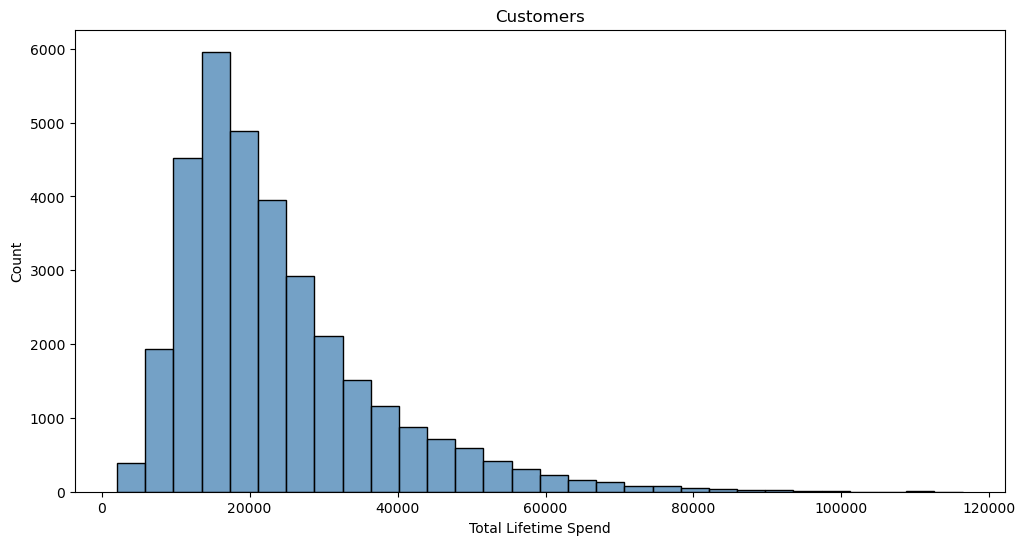

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=df, x='total_lifetime_spend', bins=30, color='steelblue')
ax.set_title('Customers')
ax.set_xlabel('Total Lifetime Spend')
ax.set_ylabel('Count')
plt.show()

In [ ]:
df['has_loyalty_card'] = df['loyalty_card_number'].notna().astype(int)
df.drop(columns=['loyalty_card_number'], inplace=True)

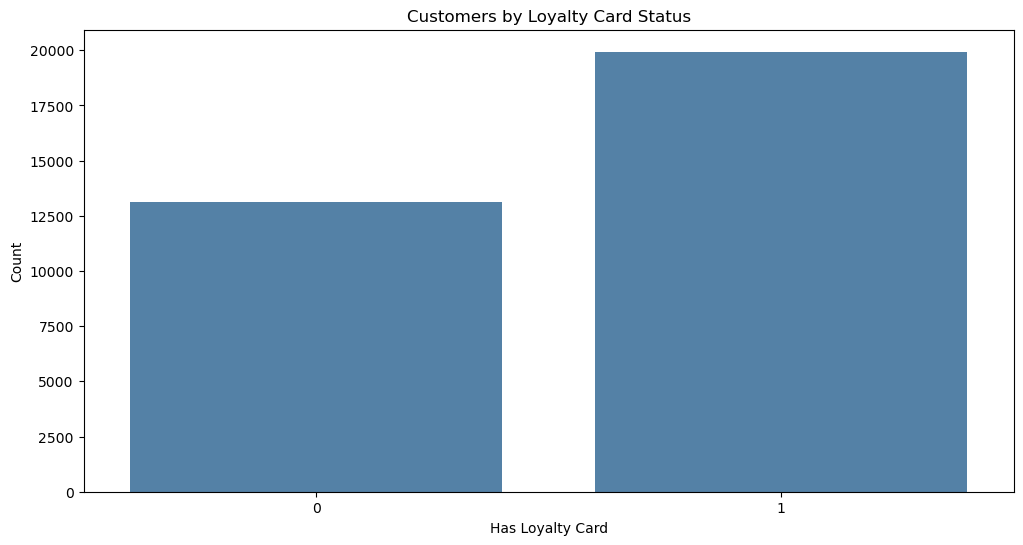

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='has_loyalty_card', color='steelblue')
ax.set_title('Customers by Loyalty Card Status')
ax.set_xlabel('Has Loyalty Card')
ax.set_ylabel('Count')
plt.show()

# 1.7 Bivariate Analysis

## 1.7.1 Correlation Matrix

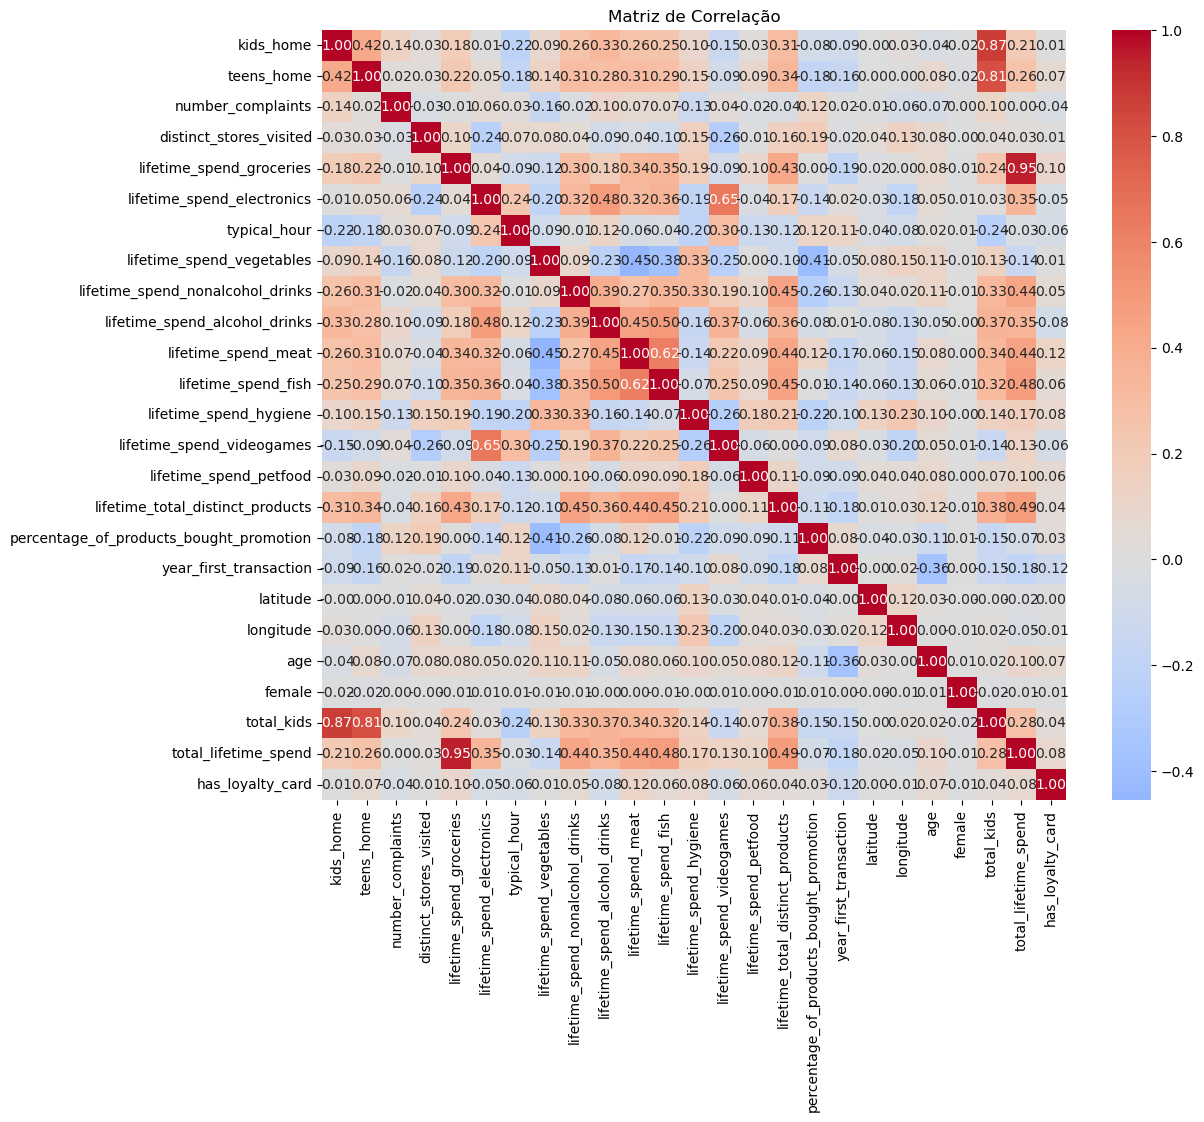

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()



Most features are weakly correlated, but spending categories clearly move together. Customers who buy meat also tend to buy fish (~0.62), and heavy grocery spenders also spend more on videogames (~0.65). This suggests there are distinct spending profiles worth clustering around.

Family structure also shows up — kids and teens at home are moderately linked (~0.42), and both show a slight negative pull on spending, meaning families tend to spend less freely across categories.

`customer_id` and `loyalty_card_number` are pure identifiers with no behavioural meaning, so they will be dropped. `birth_month` and `birth_day` are also likely to go since they carry no meaningful signal about customer behaviour — we compute `age` (in years) instead for modelling.


# 1.7 Final Insights



Based on the exploratory data analysis conducted, the following preprocessing steps will be carried out before clustering.

We will start by **dropping identifier and low-signal features** — `customer_id`, `customer_name`, `loyalty_card_number`, `latitude` and `longitude`. The first three carry no behavioural meaning, while the remaining ones showed near-zero variance and no meaningful signal across the analysis. We will keep `age` (computed from `customer_birthdate`) for modelling.

`percentage_of_products_bought_promotion` presented negative values which are not interpretable and will need to be investigated and cleaned before proceeding.

All **spending features** are heavily right-skewed with significant outliers, so we will apply a **log transformation** followed by **outlier capping** to reduce the influence of extreme values on cluster centroids. After that, all features will be **standardized with StandardScaler** to ensure no single variable dominates due to scale differences.

Since several spending features are strongly correlated, we will apply **PCA** to reduce dimensionality and eliminate redundancy, retaining 90% of the variance. Finally, `customer_gender` will be **encoded** before being fed into the algorithm.

In [ ]:
df

,customer_name,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,age,female,total_kids,total_lifetime_spend,has_loyalty_card
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,...,189.0,0.631599,2020.0,38.794428,-9.215739,56.0,1,2.0,18590.0,1
4,Bsc. Glenda Bauman,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,...,130.0,0.149890,2013.0,38.751711,-9.179611,50.0,1,1.0,20233.0,1
5,Msc. Antonio Campbell,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,...,81.0,0.069126,2005.0,38.780678,-9.160656,54.0,0,0.0,15549.0,0
7,John Kelling,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,...,92.0,0.253609,2021.0,38.739548,-9.148679,43.0,0,0.0,14952.0,1
8,Arthur Dematteo,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,...,6.0,0.186569,2021.0,38.733071,-9.188188,56.0,0,0.0,25797.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39996,Joshua Howard,0.0,0.0,2.0,1.0,475.0,13488.0,NaN,190.0,573.0,...,162.0,0.261352,2014.0,38.742306,-9.163971,53.0,0,0.0,19920.0,0
39997,Anthony Hines,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,291.0,497.0,...,97.0,0.143479,2014.0,38.748505,-9.193445,71.0,0,1.0,29520.0,0
39998,Edna Hasselman,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,1600.0,494.0,...,206.0,0.181917,2012.0,38.776003,-9.137943,81.0,1,2.0,14093.0,0


In [ ]:
df.to_csv('customer_info_engineered.csv', index=False)